In [61]:
import tensorflow as tf

In [62]:
import numpy as np

In [63]:
import pandas as pd

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
train_df = pd.read_csv("/content/drive/MyDrive/HAR_PROJECT/datasets/train_merged_9features_clean.csv")

In [66]:
feature_columns = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

X = train_df[feature_columns]

y = train_df["label_id"]

In [67]:
x_numpy=X.to_numpy()

In [68]:
x_numpy.shape

(941056, 9)

In [69]:
x_train=x_numpy.reshape(-1,128,9)

In [70]:
x_train.shape

(7352, 128, 9)

In [71]:
y_numpy=y.to_numpy()

In [72]:
y_train=y_numpy[::128]

In [73]:
x_train[0][0]

array([ 1.808515e-04,  1.076681e-02,  5.556068e-02,  3.019122e-02,
        6.601362e-02,  2.285864e-02,  1.012817e+00, -1.232167e-01,
        1.029341e-01])

In [74]:
y_train=y_train-1

In [75]:
label_map = {
    0:"Walking",
    1:"Walking Upstairs",
    2:"Walking Downstairs",
    3:"Sitting",
    4:"Standing",
    5:"Laying"
}



In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler=StandardScaler()

In [78]:
x_flat=x_train.reshape(-1,9)

In [79]:
print(x_flat.shape)

(941056, 9)


In [80]:
x_scaled=scaler.fit_transform(x_flat)

In [81]:
x_train=x_scaled.reshape(-1,128,9)

In [82]:
x_train[0][0]

array([ 0.00419384,  0.0903319 ,  0.52242331,  0.07296867,  0.17503377,
        0.0889396 ,  0.50244317, -0.38868022,  0.04594052])

In [83]:
from tensorflow.keras.models import Sequential

In [84]:
from tensorflow.keras.layers import (Conv1D,MaxPooling1D,LSTM,Dropout,Dense)

In [85]:
model=Sequential()

In [86]:
model.add(Conv1D(filters=64,kernel_size=3,activation='relu',input_shape=(128,9)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
model.add(MaxPooling1D(pool_size=2))

In [88]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 1,792 (7.00 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
model.add(Conv1D(filters=128,kernel_size=3,activation='relu'))

In [90]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,496 (103.50 KB)

 Trainable params: 26,496 (103.50 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.add(MaxPooling1D(pool_size=2))

In [92]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,496 (103.50 KB)

 Trainable params: 26,496 (103.50 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.add(LSTM(100))

In [94]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        91,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,096 (461.31 KB)

 Trainable params: 118,096 (461.31 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.add(Dropout(0.5))

In [96]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,096 (461.31 KB)

 Trainable params: 118,096 (461.31 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.add(Dense(6,activation='softmax'))

In [98]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,702 (463.68 KB)

 Trainable params: 118,702 (463.68 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [100]:
test_df = pd.read_csv("/content/drive/MyDrive/HAR_PROJECT/datasets/test_merged_9features_clean.csv")

In [101]:
 x_test= test_df[feature_columns]

y_test= test_df["label_id"]

In [102]:
x_test=x_test.to_numpy()

In [103]:
y_test=y_test.to_numpy()

In [104]:
y_test=y_test[::128]

In [105]:
y_test=y_test-1

In [106]:
y_test.shape

(2947,)

In [107]:
x_test=scaler.fit_transform(x_test)

In [108]:
x_test=x_test.reshape(-1,128,9)

In [109]:
history=model.fit(x_train,y_train,epochs=20,batch_size=32,validation_split=0.2)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8172 - loss: 0.4654 - val_accuracy: 0.8926 - val_loss: 0.3446
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9434 - loss: 0.1556 - val_accuracy: 0.9184 - val_loss: 0.2314
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9447 - loss: 0.1240 - val_accuracy: 0.9266 - val_loss: 0.2513
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9546 - loss: 0.1009 - val_accuracy: 0.9368 - val_loss: 0.2500
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9597 - loss: 0.0908 - val_accuracy: 0.9354 - val_loss: 0.2480
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9505 - loss: 0.1181 - val_accuracy: 0.9334 - val_loss: 0.2314
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9561 - loss: 0.0864 - val_accuracy: 0.9252 - val_loss: 0.2605
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9614 - loss: 0.0785 - val_accuracy:

In [110]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9318 - loss: 0.2825
Test Loss: 0.28249192237854004
Test Accuracy: 0.931795060634613


In [111]:
predictions=model.predict(x_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [112]:
predictions.shape

(2947, 6)

In [113]:
y_pred=np.argmax(predictions,axis=1)

In [114]:
y_pred[0]

np.int64(4)

In [115]:
y_pred.shape

(2947,)

In [116]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [117]:
c=confusion_matrix(y_test,y_pred)

In [118]:
c

array([[496,   0,   0,   0,   0,   0],
       [  0, 450,  20,   1,   0,   0],
       [  2,   1, 417,   0,   0,   0],
       [  0,   4,   0, 427,  55,   5],
       [  0,   1,   0, 112, 419,   0],
       [  0,   0,   0,   0,   0, 537]])

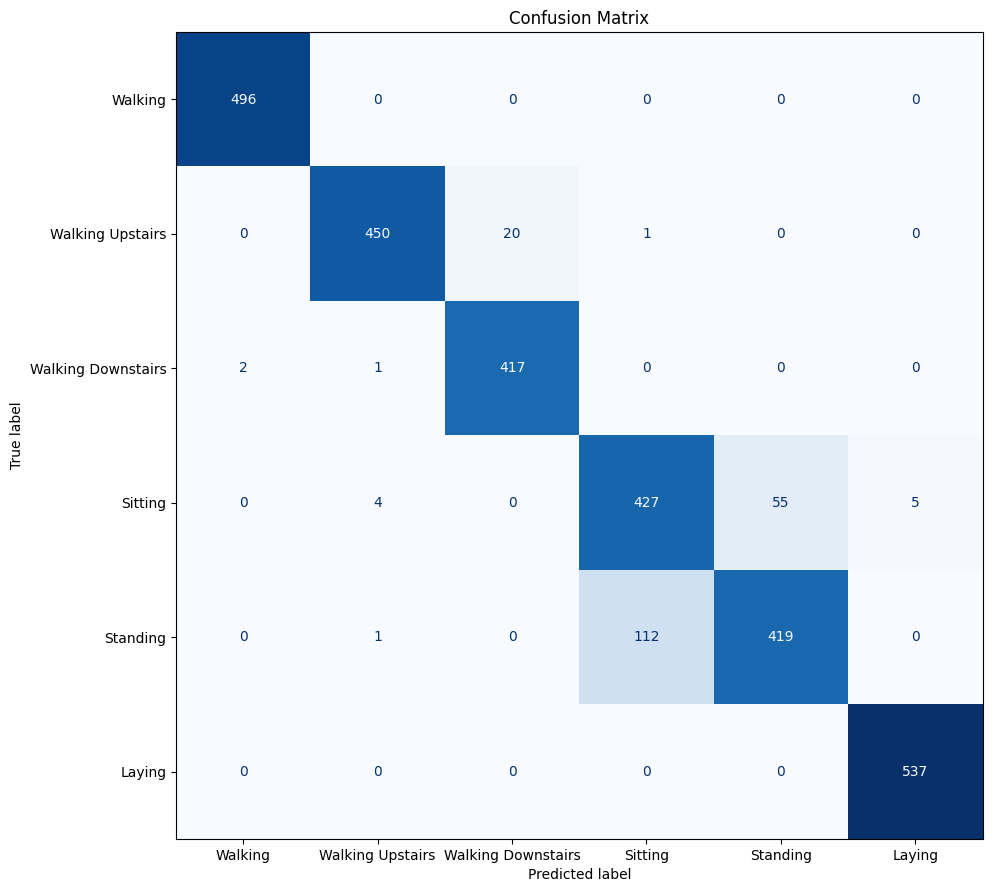

In [119]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=c,
    display_labels=list(label_map.values())
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [120]:
model.save("har_cnn_lstm_model.keras")

In [121]:
from sklearn.metrics import classification_report

In [122]:
print(classification_report(y_test, y_pred, target_names=list(label_map.values())))

                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       496
  Walking Upstairs       0.99      0.96      0.97       471
Walking Downstairs       0.95      0.99      0.97       420
           Sitting       0.79      0.87      0.83       491
          Standing       0.88      0.79      0.83       532
            Laying       0.99      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



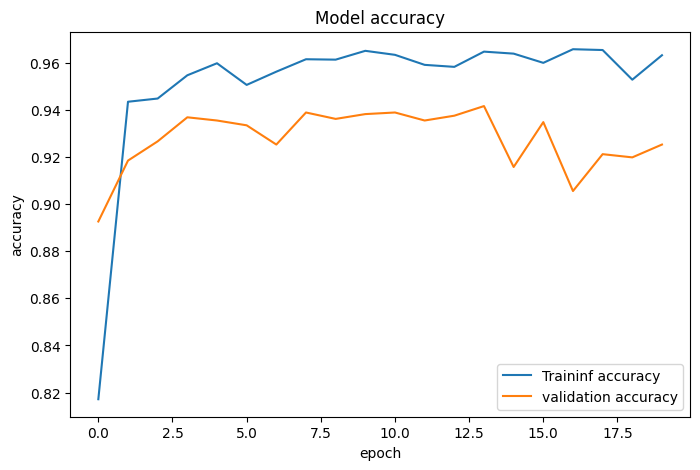

In [124]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Traininf accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.title('Model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.savefig("model_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

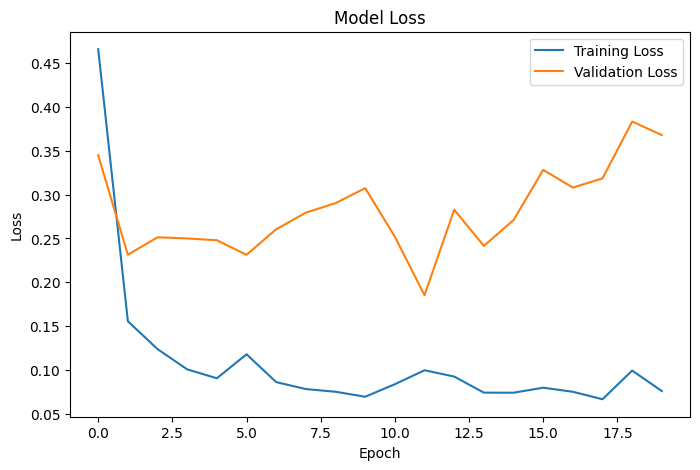

In [125]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_graph.png", dpi=300, bbox_inches="tight")

plt.show()

In [127]:
model.save("har_cnn_lstm_model.keras")